In [176]:
# Import necessary libraries

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import seaborn as sns 
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,TimeSeriesSplit


In [177]:
#Load the dataset

data=pd.read_csv('/kaggle/input/datasets/ganusha/dataset-jan-feb-foil/Uber-Jan-Feb-FOIL.csv')

In [178]:
#Display the basic info about the dataset
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   dispatching_base_number  354 non-null    object
 1   date                     354 non-null    object
 2   active_vehicles          354 non-null    int64 
 3   trips                    354 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 11.2+ KB
None


**Data Preprocessing**

In [179]:
#Convert date/Time to datetime object

data['date']=pd.to_datetime(data['date'])
print(data['date'])

0     2015-01-01
1     2015-01-01
2     2015-01-01
3     2015-01-01
4     2015-01-01
         ...    
349   2015-02-28
350   2015-02-28
351   2015-02-28
352   2015-02-28
353   2015-02-28
Name: date, Length: 354, dtype: datetime64[ns]


In [180]:
#Extracting useful information from Date/Time

data['Hour']=data['date'].dt.hour
data['Day']=data['date'].dt.day
data['Dayofweek']=data['date'].dt.dayofweek
data['Month']=data['date'].dt.month

**Exploratory Data Analysis**

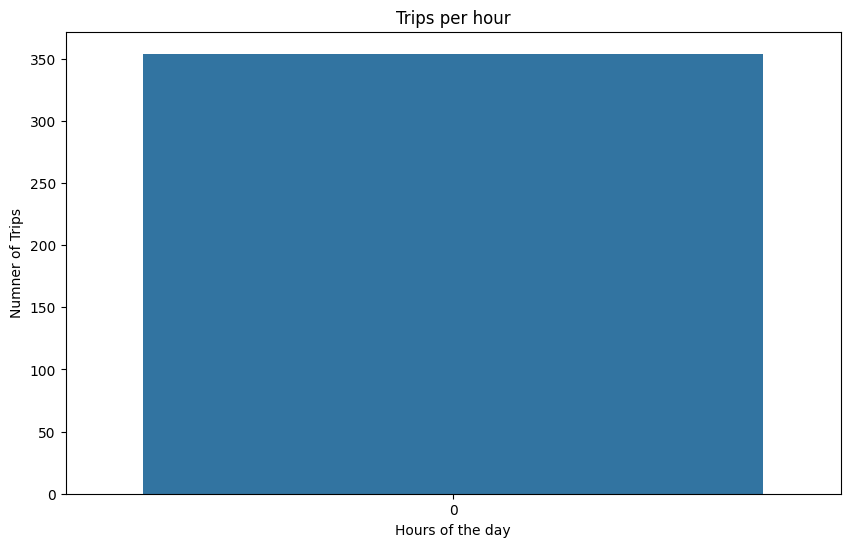

In [181]:
#Plotting the number of trips per hour

plt.figure(figsize=(10,6))
sns.countplot(x='Hour',data=data)

plt.title('Trips per hour')
plt.xlabel('Hours of the day')
plt.ylabel('Numner of Trips')

plt.show()

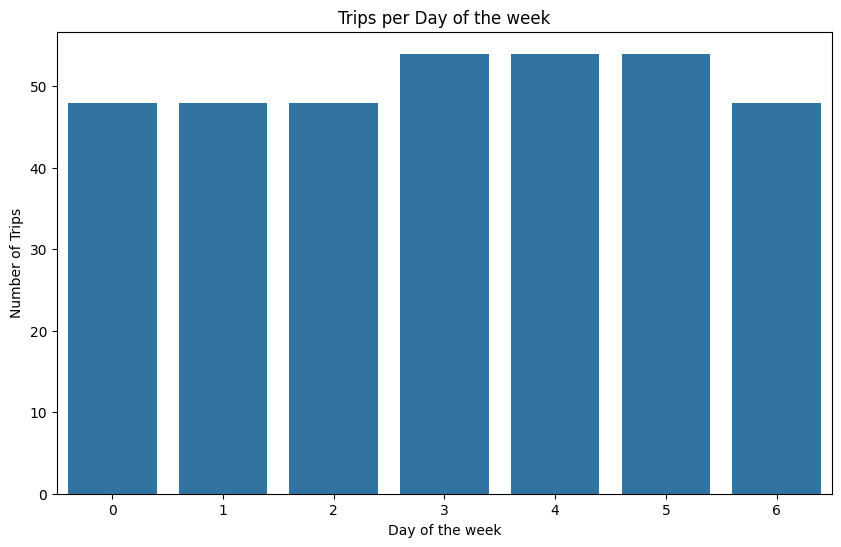

In [182]:
#plotting number of trips per dayof the week

plt.figure(figsize=(10,6))
sns.countplot(x='Dayofweek',data=data)

plt.title('Trips per Day of the week')
plt.xlabel('Day of the week')
plt.ylabel('Number of Trips')

plt.show()

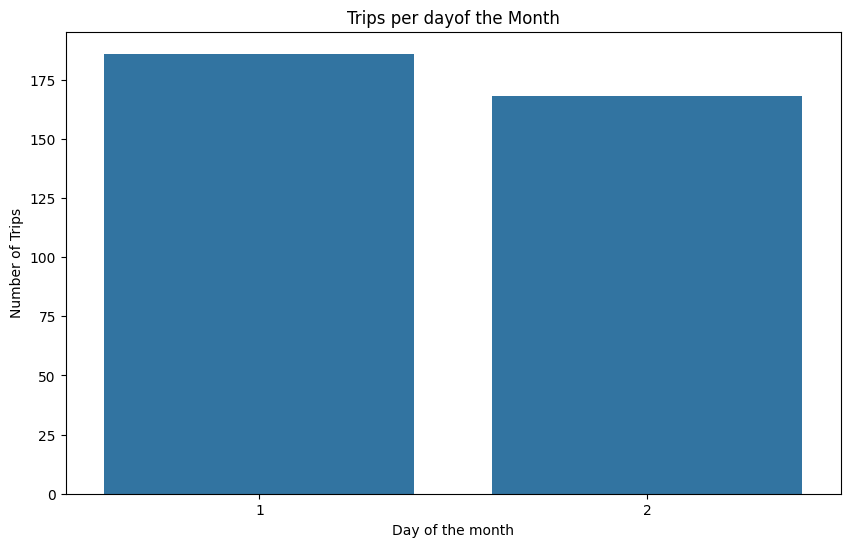

In [183]:
#plotting the number of trips for day of the month

plt.figure(figsize=(10,6))
sns.countplot(x='Month',data=data)

plt.title('Trips per dayof the Month')
plt.xlabel('Day of the month')
plt.ylabel('Number of Trips')

plt.show()

**Feature Engineering**

In [184]:
data.columns

Index(['dispatching_base_number', 'date', 'active_vehicles', 'trips', 'Hour',
       'Day', 'Dayofweek', 'Month'],
      dtype='object')

In [185]:
# Create dummy variables for categorical features

data = pd.get_dummies(data, columns=['dispatching_base_number'], drop_first=True)

In [186]:
#Define features and target variables

x=data[['active_vehicles','Month','Day','Dayofweek']]
y=data['trips']

In [187]:
#Split the data into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

print(x_train)
print(x_test)
print(y_train)
print(y_test)

     active_vehicles  Month  Day  Dayofweek
110              238      1   19          0
261              599      2   13          4
318              966      2   23          0
153             3012      1   26          0
19               812      1    4          6
..               ...    ...  ...        ...
71              1323      1   12          0
106             1056      1   18          6
270             1261      2   15          6
348              994      2   28          5
102              177      1   18          6

[247 rows x 4 columns]
     active_vehicles  Month  Day  Dayofweek
220             4170      2    6          4
42               262      1    8          3
286             1066      2   17          1
181              225      1   31          5
56               949      1   10          5
..               ...    ...  ...        ...
233              176      2    8          6
194              275      2    2          0
250              450      2   11          2
349     

**Model Building**

In [188]:
#Train a Random Forest Regressor
Rfr=RandomForestRegressor(random_state=42)
Rfr.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [189]:
#Predict on the test set
y_pred=Rfr.predict(x_test)

**Model Evaluation**

In [190]:
#find Mean Squared Error and Linear Regression

print("Mean squared Error:",mean_squared_error(y_test,y_pred))
print("R^2 Score:",r2_score(y_test,y_pred))

Mean squared Error: 1524009.896464486
R^2 Score: 0.9873223292738049


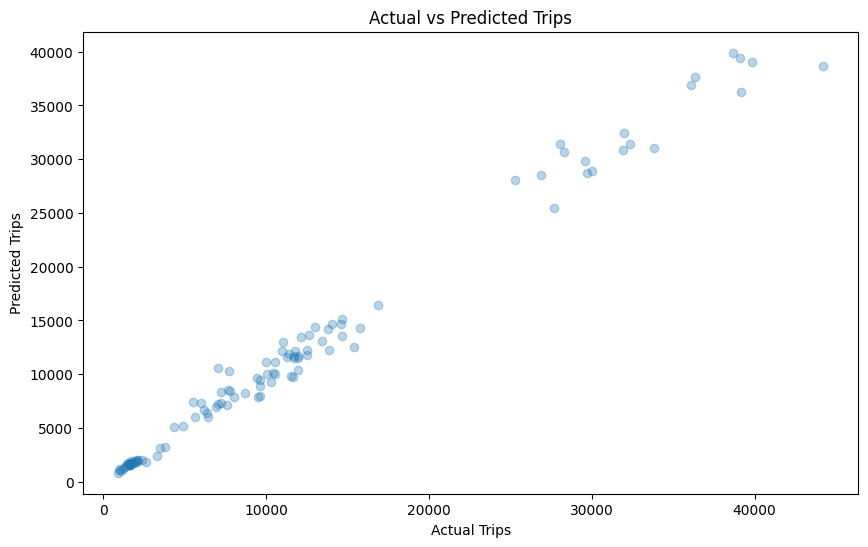

In [191]:
# visualization of predictions Active vs Predicted Trips

plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred,alpha=0.3)
plt.xlabel('Actual Trips')
plt.ylabel('Predicted Trips')
plt.title('Actual vs Predicted Trips')

plt.show()

**Observation:**

1. Positive Correlation: The predicted trips closely follow the actual trips,showing a strong positive correlation. As actual trips increase, predicted trips also increase.
2. Accuracy at Lower Values : Predictions are highly accurate for lower trip counts (dense cluster near the origin), indicating the model handles small values very well.
3. Slight Under/Overestimation at Higher Values : For very high trip counts (above~25,000),some points deviate from the perfect diagonal line, suggesting minor overestimation or underestimation by the model.
4. Overall Model Performance:The Overall scatter indicates the model predicts trips reliably across most ranges,with few outliners.


In [192]:
#Importing the necessary libraries and function.

#This first step is to import all necessary libraries and include useful functions to make the code below more readable.
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import seaborn as sns
import xgboost as xgb
import glob
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from xgboost import plot_importance, plot_tree
from sklearn.model_selection import train_test_split
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,TimeSeriesSplit


In [193]:
def PlotDecomposition(result):
    plt.figure(figsize=(22,18))
    plt.subplot(4,1,1)
    plt.plot(result.observed,label='Observed',lw=1)
    plt.legend(loc='upper left')
    plt.subplot(4,1,2)
    plt.plot(result.trend,label='Trend',lw=1)
    plt.legend(loc='upper left')
    plt.subplot(4, 1, 3)
    plt.plot(result.seasonal, label='Seasonality',lw=1)
    plt.legend(loc='upper left')
    plt.subplot(4, 1, 4)
    plt.plot(result.resid, label='Residuals',lw=1)
    plt.legend(loc='upper left')
    plt.show()
def CalculateError(pred,sales):
    percentual_errors = []
    for A_i, B_i in zip(sales, pred):
        percentual_error = abs((A_i- B_i) / B_i)
        percentual_errors.append(percentual_error)
    return sum(percentual_errors) / len(percentual_errors)
def PlotPredictions(plots,title):
    plt.figure(figsize=(18, 8))
    
    for plot in plots:
        plt.plot(plot[0], plot[1], label=plot[2], 
                 linestyle=plot[3],color=plot[4],lw=1)
        
    plt.xlabel('Date')
    plt.ylabel("Trips")
    plt.title(title)
    plt.legend()
    plt.xticks(rotation=30, ha='right')
    
    plt.show()
        
def create_lagged_features(data, window_size):
    X, y = [], []
    for i in range(len(data)- window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)   

In [194]:
import glob
import pandas as pd

files = glob.glob('/kaggle/input/datasets/ganusha/dataset-april-sep/*.csv')

print(files)   # confirm all 6 files

dataframes = [pd.read_csv(f) for f in files]

uber2014 = pd.concat(dataframes, ignore_index=True)

print(uber2014.shape)

['/kaggle/input/datasets/ganusha/dataset-april-sep/uber-raw-data-may14.csv', '/kaggle/input/datasets/ganusha/dataset-april-sep/uber-raw-data-apr14.csv', '/kaggle/input/datasets/ganusha/dataset-april-sep/uber-raw-data-jul14.csv', '/kaggle/input/datasets/ganusha/dataset-april-sep/uber-raw-data-jun14.csv', '/kaggle/input/datasets/ganusha/dataset-april-sep/uber-raw-data-sep14.csv', '/kaggle/input/datasets/ganusha/dataset-april-sep/uber-raw-data-aug14.csv']
(4534327, 4)


In [195]:
uber2014['Count'] = 1

In [196]:
#Read and concatenate all csv files
import pandas as pd

dataframes = [pd.read_csv(f) for f in files]

uber2014 = pd.concat(dataframes, ignore_index=True)

print(uber2014.head())
print("Total rows:", len(uber2014))

          Date/Time      Lat      Lon    Base
0  5/1/2014 0:02:00  40.7521 -73.9914  B02512
1  5/1/2014 0:06:00  40.6965 -73.9715  B02512
2  5/1/2014 0:15:00  40.7464 -73.9838  B02512
3  5/1/2014 0:17:00  40.7463 -74.0011  B02512
4  5/1/2014 0:17:00  40.7594 -73.9734  B02512
Total rows: 4534327


In [197]:
#Now make sure that column is set to datetime,sorted and with an adequate name
uber2014['Date/Time'] = pd.to_datetime(uber2014['Date/Time'])
uber2014 = uber2014.sort_values('Date/Time').rename(columns={'Date/Time':'Date'})
uber2014.set_index('Date', inplace=True)

In [198]:
#Group by hour and count occurrencesof 'Base'
hourly_counts=uber2014['Base'].resample('h').count()
#Convert the series to a dataframe 
uber2014=hourly_counts.reset_index()
#Rename columns for clarity
uber2014.columns=['Date','Count']
uber2014.set_index('Date',inplace=True)

In [199]:
#find the number of rows
uber2014.head()

,Count
Date,
2014-04-01 00:00:00,138
2014-04-01 01:00:00,66
2014-04-01 02:00:00,53
2014-04-01 03:00:00,93
2014-04-01 04:00:00,166


**#Choosing the optimal train/test sets**

In order to choose the correct train/test sets, we need to fist visualize the series,then do a seaonal decompose if the trend can inform us of a suggested approach to that split.


In [200]:
print(uber2014.index.min())
print(uber2014.index.max())

2014-04-01 00:00:00
2014-09-30 22:00:00


In [201]:
print(uber2014.index.min(), uber2014.index.max())

2014-04-01 00:00:00 2014-09-30 22:00:00


In [202]:
uber2014.resample('M').size()

Date
2014-04-30    720
2014-05-31    744
2014-06-30    720
2014-07-31    744
2014-08-31    744
2014-09-30    719
Freq: ME, dtype: int64

In [203]:
uber2014.index.to_series().diff().value_counts().head()

Date
0 days 01:00:00    4390
Name: count, dtype: int64

In [204]:
uber2014['Count'].loc['2014-08':'2014-09'].head(20)

Date
2014-08-01 00:00:00     734
2014-08-01 01:00:00     451
2014-08-01 02:00:00     289
2014-08-01 03:00:00     318
2014-08-01 04:00:00     412
2014-08-01 05:00:00     604
2014-08-01 06:00:00     928
2014-08-01 07:00:00    1307
2014-08-01 08:00:00    1337
2014-08-01 09:00:00    1153
2014-08-01 10:00:00    1109
2014-08-01 11:00:00    1079
2014-08-01 12:00:00    1085
2014-08-01 13:00:00    1398
2014-08-01 14:00:00    1585
2014-08-01 15:00:00    1885
2014-08-01 16:00:00    2122
2014-08-01 17:00:00    2242
2014-08-01 18:00:00    2196
2014-08-01 19:00:00    2120
Name: Count, dtype: int64

In [205]:
print(files)

['/kaggle/input/datasets/ganusha/dataset-april-sep/uber-raw-data-may14.csv', '/kaggle/input/datasets/ganusha/dataset-april-sep/uber-raw-data-apr14.csv', '/kaggle/input/datasets/ganusha/dataset-april-sep/uber-raw-data-jul14.csv', '/kaggle/input/datasets/ganusha/dataset-april-sep/uber-raw-data-jun14.csv', '/kaggle/input/datasets/ganusha/dataset-april-sep/uber-raw-data-sep14.csv', '/kaggle/input/datasets/ganusha/dataset-april-sep/uber-raw-data-aug14.csv']


In [206]:
import os

os.listdir('/kaggle/input/datasets/ganusha/dataset-april-sep')

['uber-raw-data-may14.csv',
 'uber-raw-data-apr14.csv',
 'uber-raw-data-jul14.csv',
 'uber-raw-data-jun14.csv',
 'uber-raw-data-sep14.csv',
 'uber-raw-data-aug14.csv']

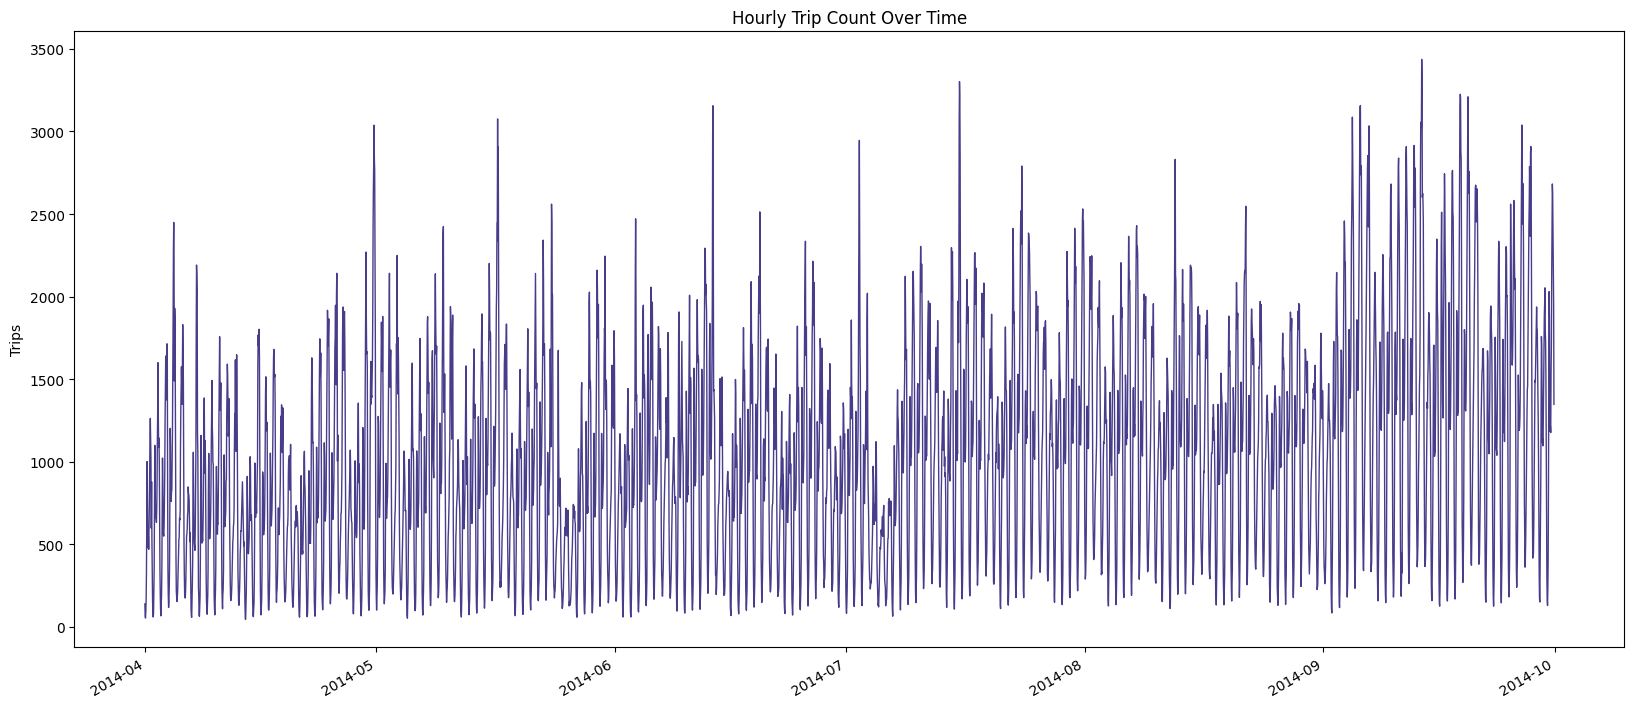

In [256]:
#let's plot the Time series

plt.figure(figsize=(20,8))
plt.plot(uber2014['Count'],linewidth=1,color='darkslateblue')
plt.title('Hourly Trip Count Over Time')
plt.ylabel('Trips')
plt.xticks(rotation=30,ha='right')

plt.show()

**Observation:**

The time series shows clear fluctuations in uber trip demand over time,indicating varying ride activity across hours.
There are frequent peaks and drops ,suggesting higher demand during busy hours and lower demand during off-peak hours.
The pattern indicates temporal trends in trip demand,which makes the dataset suitable for time-based predictive modeling.

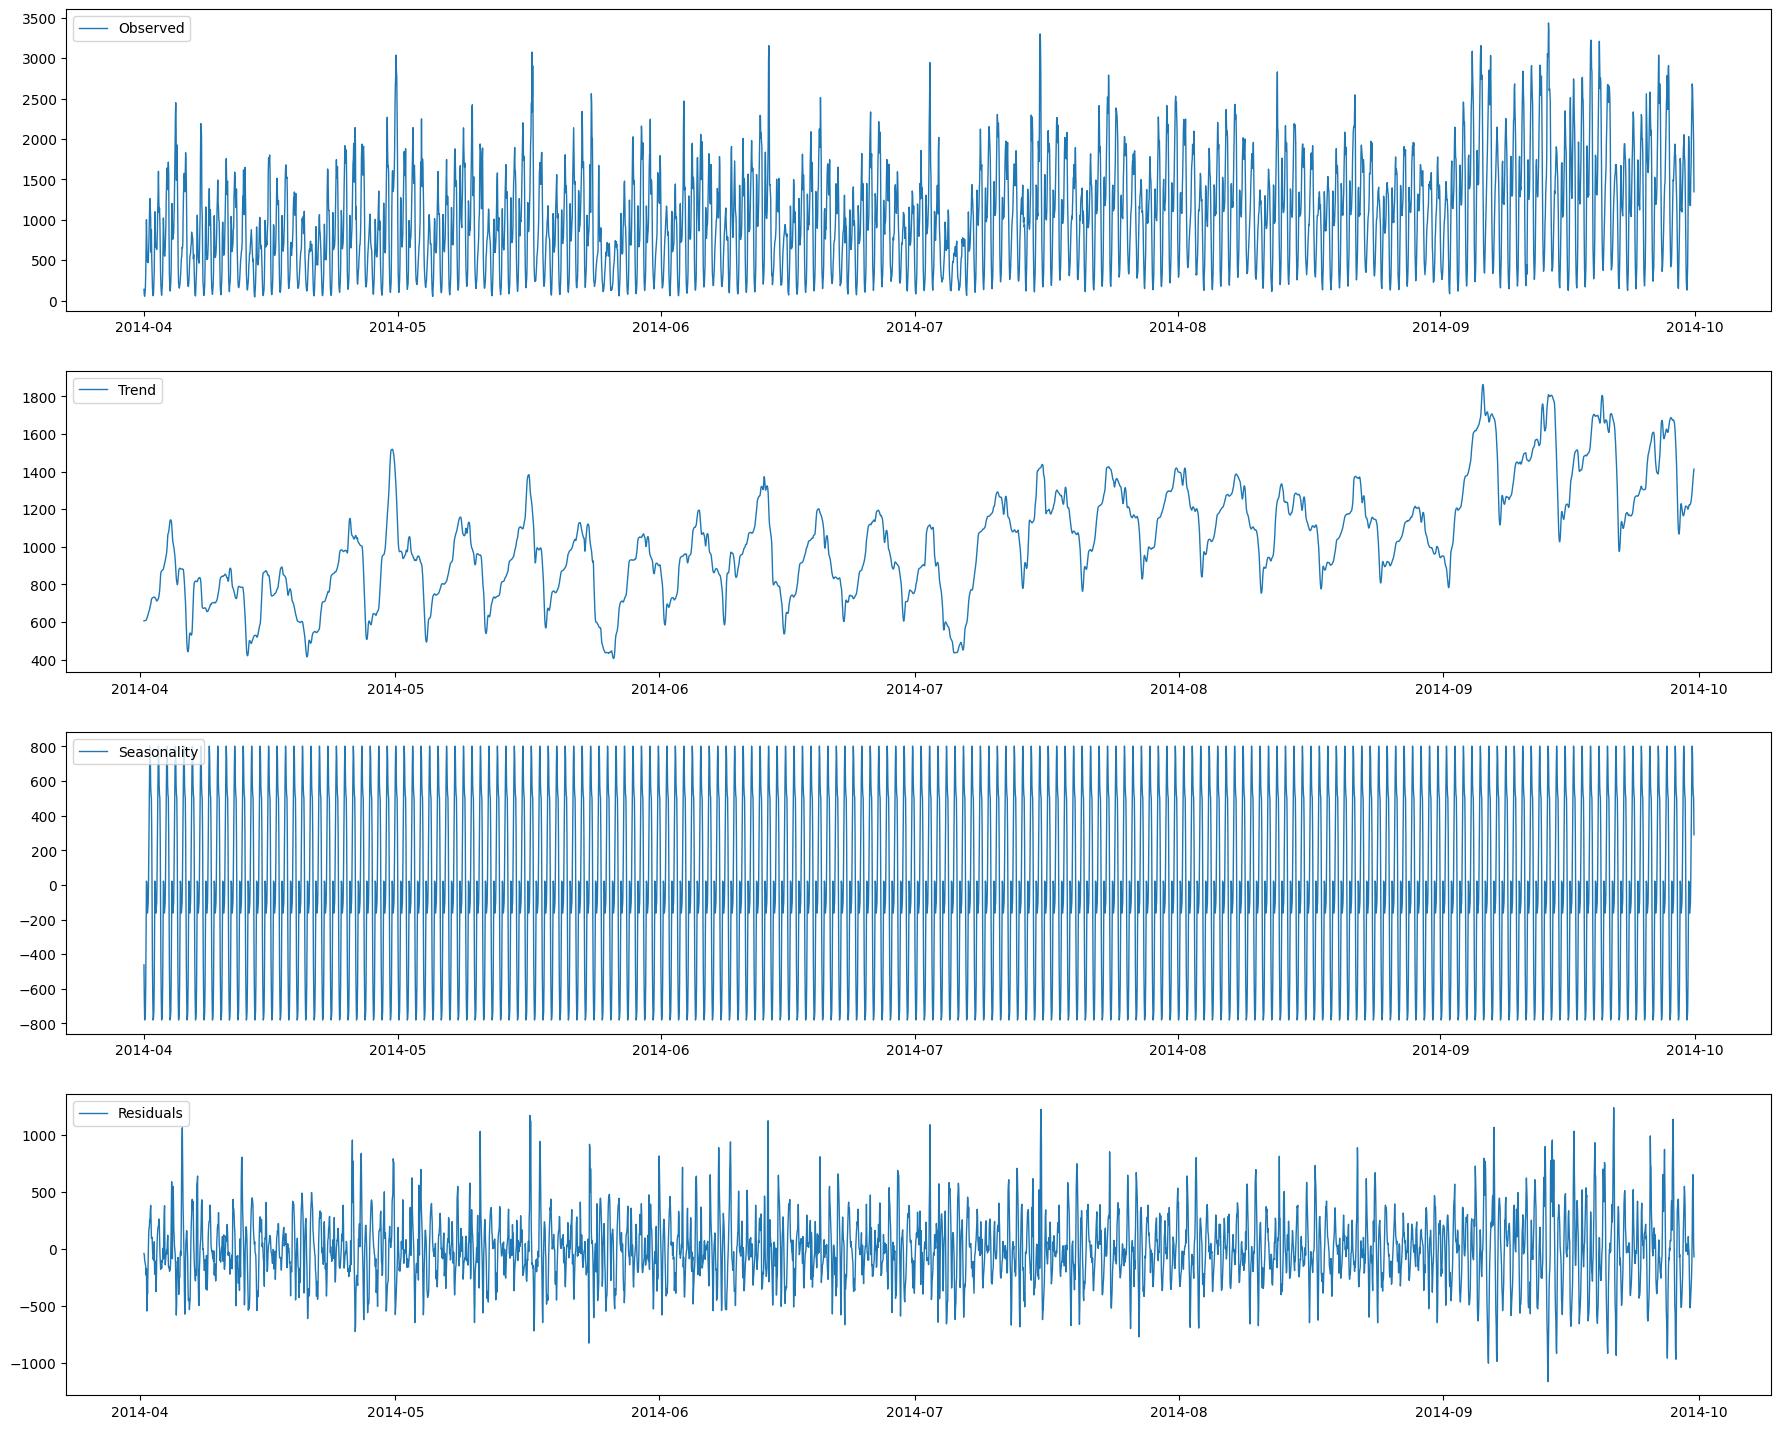

In [258]:
# Seasonal Decomposition :

hourly=uber2014['Count'].resample('H').sum()
result=seasonal_decompose(hourly,model='add',period=24*1)
PlotDecomposition(result)

**Observation :**

Uber trip demand shows an increasing trend from april to september 2014

The data exhibits strong daily seasonality with repeating hourly patterns

Peak demand occurs at specific hours of the day due to commuting  and nightlife activity.

Residual values indicate random variations not explained by trend or seasonal components.

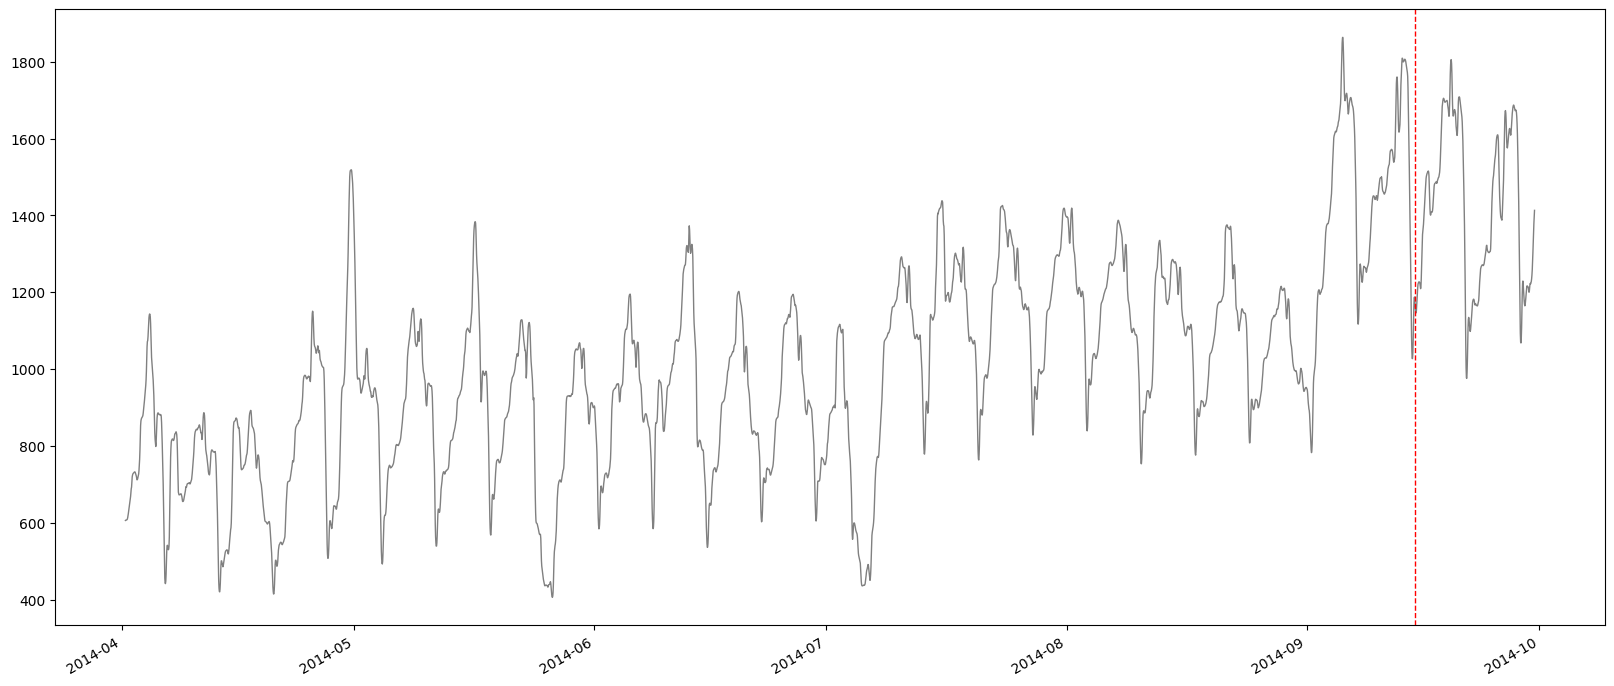

In [209]:
cutoff_date='2014-09-15 00:00:00'
plt.figure(figsize=(20,8))
plt.plot(result.trend,linewidth=1,color='gray')
plt.axvline(x=pd.Timestamp(cutoff_date),color='red',linestyle='--',linewidth=1)
plt.xticks(rotation=30,ha='right')
plt.show()

**Observation :**

As seen above , the trend stays relatively stable until around september 2014, and then increases to 4 more peaks. Leaving up to thr first 2 peaks as train data and the remaining 2 as test would be sufficient . This is particulary important, because if we did the usual 80/20 split, we would likely encounter errors due to the said trend increase.

In [210]:
uber2014_train=uber2014.loc[:cutoff_date]
uber2014_test=uber2014.loc[cutoff_date:]

<Axes: title={'center': 'Train/Test Sets'}, xlabel='Date'>

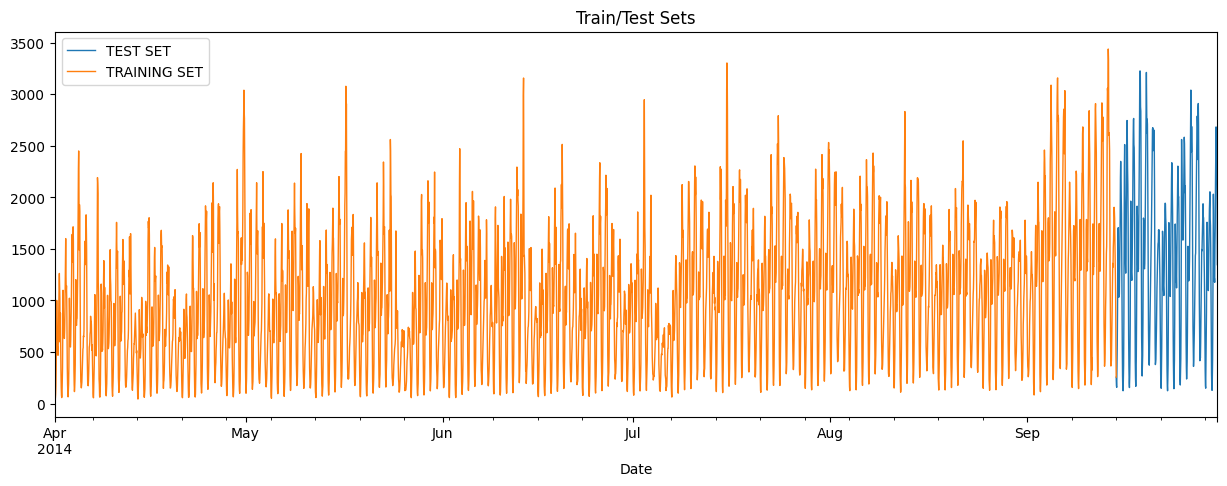

In [211]:
uber2014_test.rename(columns={'Count':'TEST SET'}).join(uber2014_train.rename(columns={'Count':'TRAINING SET'}),
                                                        how='outer').plot(figsize=(15,5),title='Train/Test Sets',
                                                                          style='-',lw=1)
                                                                          

In [212]:
#set the window size
window_size=24

#Split the data into training and test sets

x_train,y_train,=create_lagged_features(uber2014_train['Count'].values,window_size)

In [213]:
test_data=np.concatenate([uber2014_train['Count'].values[-window_size:],
                          uber2014_test['Count'].values])
x_test,y_test=create_lagged_features(test_data, window_size)

seed=12345

**XGBoost Model**

In [214]:
#XGBoost is one of the strongest ML algorithms available. However,it is usally prone to overfitting. We avoid it by doing Cross 
#validation and the fine tuning the training process

tscv=TimeSeriesSplit(n_splits=3)

In [215]:
xgb_param_grid={
    'n_estimators':[100,200,300],
    'max_depth':[3,6,9],
    'learning_rate':[0.01,0.1,0.3],
    'subsample':[0.6,0.8,1.0],
    'colsample_bytree':[0.6,0.8,1.0]
}

In [216]:
xgb_model=xgb.XGBRegressor(objective='reg:squarederror',random_state=seed)

In [217]:
from sklearn.model_selection import RandomizedSearchCV

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,        #
    n_iter=10,
    cv=tscv, 
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1,verbose=1,
    random_state=seed
)

xgb_random_search.fit(x_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamm...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.3],
                                        'max_depth': [3, 6, 9],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=12345,
                   scoring='neg_mean_absolute_percentage_error', verbose=1)

**Observation :**

RandomizedSearchCV was used to identify the optimal hyperparameters for the XGBoost model.
The tuning process improved the model's ability to capture patterns in uber trip demand and enhanced prediction performance.

In [218]:
print("Best XGBoost parameters:", xgb_random_search.best_params_)

Best XGBoost parameters: {'subsample': 0.6, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [219]:
xgb_predictions=xgb_random_search.best_estimator_.predict(x_test)
print(xgb_predictions)

[ 183.55527  193.2633   224.91237  232.07797  499.22418  805.44867
 1242.6776  1309.7672  1533.5721  1352.0681  1235.0215  1081.1907
 1109.9171  1225.6696  1428.9327  1676.8224  2014.2479  2279.3958
 2148.4915  1980.3055  1697.5856  1394.4088   803.11597  595.8154
  322.8848   177.05157  194.3974   280.45886  350.40295  848.45074
 1327.2858  1942.7133  1921.5505  2127.6003  1617.7091  1540.3694
 1345.824   1463.7529  1607.9232  2099.698   2449.8936  2611.3489
 2696.8013  2405.7456  2079.5564  1749.7574  1304.0634   691.7768
  375.95697  232.97621  165.72664  233.85796  498.30914  832.66754
 1270.5654  1781.2496  1729.2767  1570.9856  1268.5312  1258.9595
 1255.5052  1532.4285  1871.9269  2105.603   2556.603   2803.9866
 2614.2437  2487.2698  2551.52    2359.6045  1690.906    928.1838
  429.17444  264.97507  195.20964  251.31647  459.01288  810.64124
 1406.0032  1690.3597  1759.9734  1362.7439  1254.2231  1295.4226
 1371.1692  1493.3181  1937.5408  2185.075   2474.4744  3055.2732
 2904.

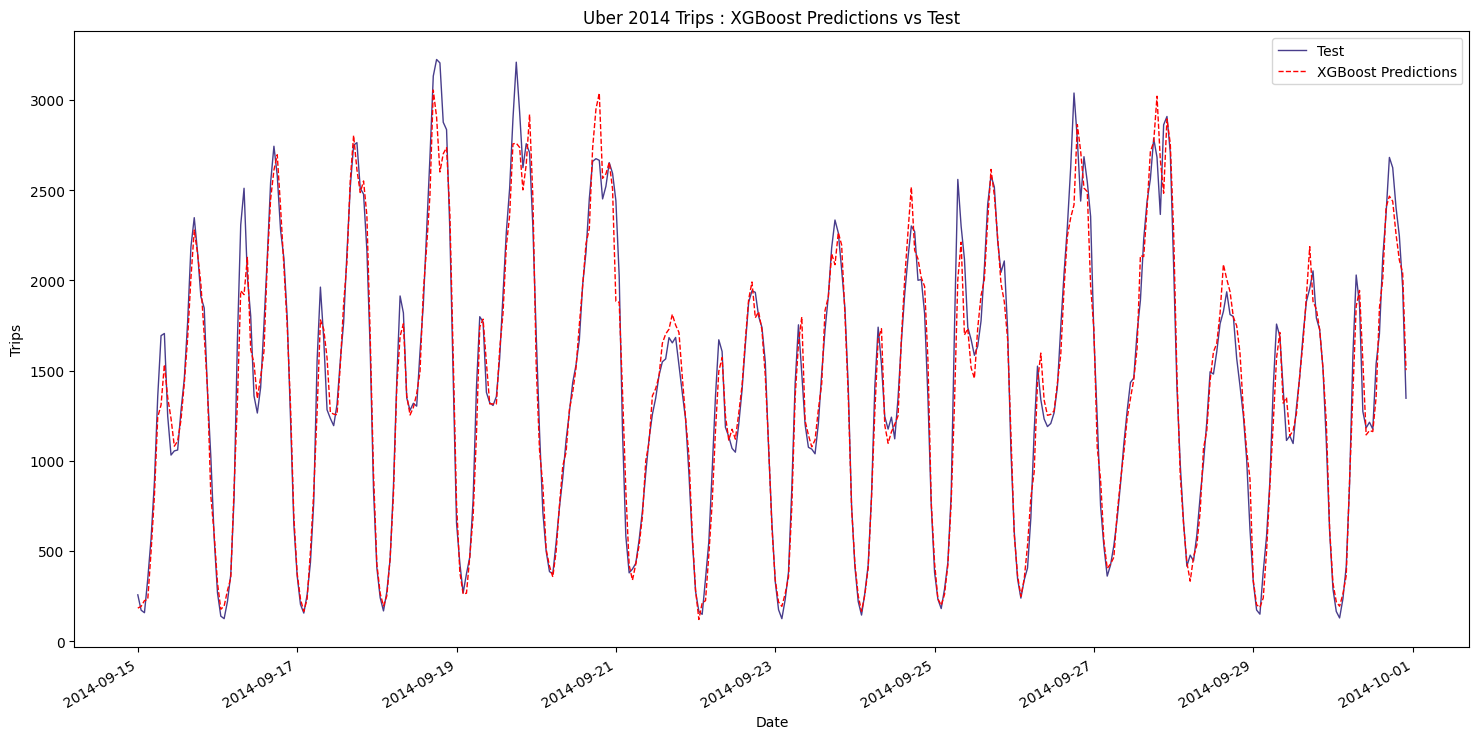

In [220]:
PlotPredictions([
    (uber2014_test.index, uber2014_test['Count'],'Test','-','darkslateblue'),
    (uber2014_test.index, xgb_predictions,'XGBoost Predictions','--','red')],
    'Uber 2014 Trips : XGBoost Predictions vs Test')

In [221]:
xgb_mape=mean_absolute_percentage_error(uber2014_test['Count'], xgb_predictions)
print(f'XGBoost MAPE:\t\t{xgb_mape:.2%}')

XGBoost MAPE:		8.37%


**Random Forest model :**

In [222]:
rf_param_grid= {
    'n_estimators':[100,200,300],
    'max_depth':[10,20,30],
    'min_samples_leaf':[1,2,4],
    'max_features':[None,'sqrt','log2']
}

In [223]:
rf_model=RandomForestRegressor(random_state=seed)

In [224]:
from sklearn.model_selection import RandomizedSearchCV

rf_random_search= RandomizedSearchCV(
    estimator=rf_model, 
    param_distributions=rf_param_grid, 
    n_iter=10,
    cv=tscv,
    n_jobs=-1,
    scoring ='neg_mean_absolute_percentage_error',
    verbose=1,
    random_state=seed
)

rf_random_search.fit(x_train,y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=RandomForestRegressor(random_state=12345),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'n_estimators': [100, 200, 300]},
                   random_state=12345,
                   scoring='neg_mean_absolute_percentage_error', verbose=1)

In [225]:
print("Best Random Forest parameters:",rf_random_search.best_params_)

Best Random Forest parameters: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}


In [226]:
rf_predictions=rf_random_search.best_estimator_.predict(x_test)
print(rf_predictions)

[ 197.78        254.8925      271.67866667  253.5397619   481.35
  806.5        1066.235      1192.18042782 1503.295      1343.5
 1235.7342381  1126.89675    1166.385      1241.11364762 1503.865
 1735.2        2014.715      2180.965      2223.47       1951.145
 1694.83333333 1419.13        848.85        600.89        322.36333333
  188.161875    182.71083333  266.03166667  365.4         818.785
 1265.87       1753.44988636 1986.685      2166.395      1542.905
 1453.54       1321.12461538 1383.79923077 1608.43       2074.35166667
 2549.5        2686.87       2692.275      2482.24       2030.325
 1864.83277778 1381.094375    717.71        362.055       223.895
  176.985       240.04938095  411.725       780.78       1284.625
 1657.83541667 1911.058125   1699.2625     1278.41360119 1255.93566667
 1289.21785714 1560.195      1842.7525     2101.73166667 2544.125
 2686.005      2823.68       2597.14       2496.94       2321.33
 1676.715       960.32        459.555       267.81        205.671

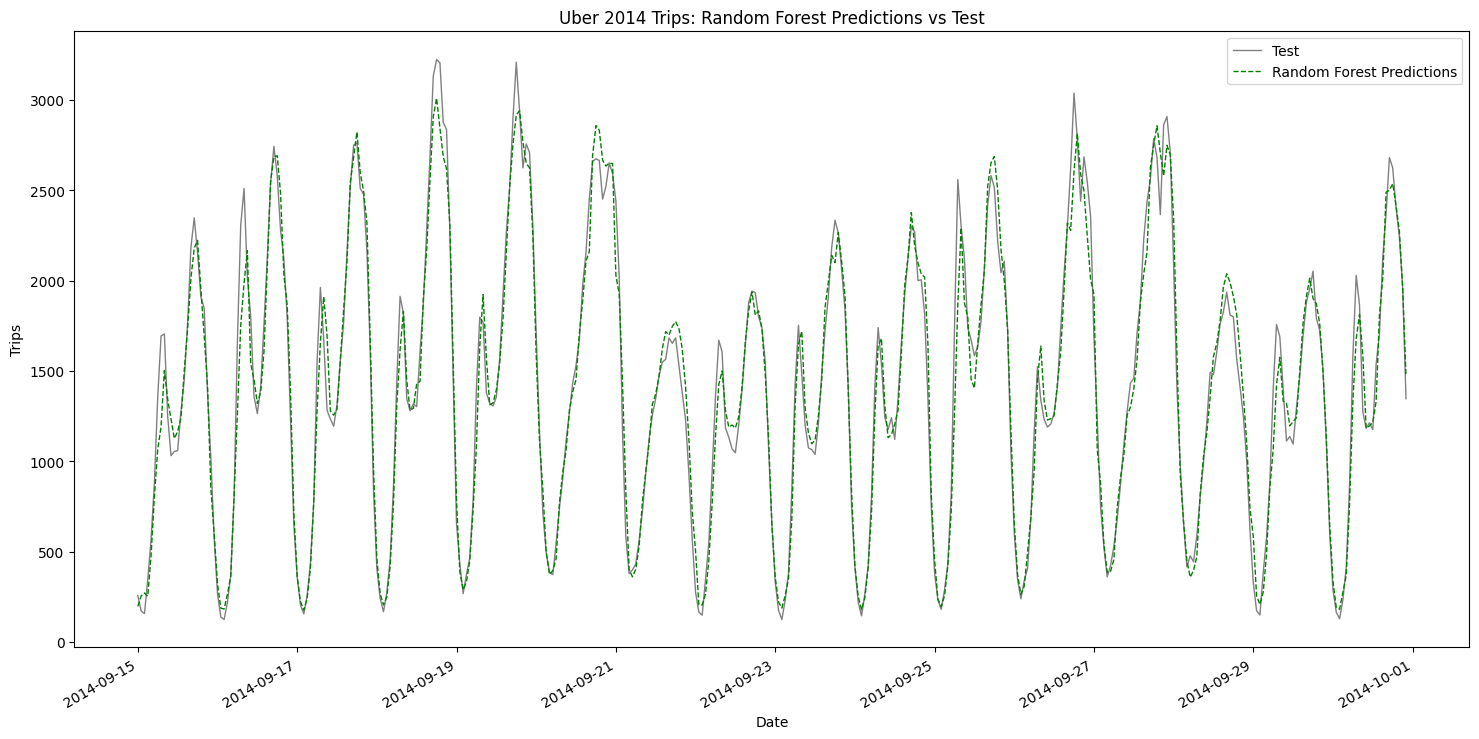

In [227]:
PlotPredictions([
    (uber2014_test.index, uber2014_test['Count'],'Test','-','gray'),
    (uber2014_test.index,rf_predictions,'Random Forest Predictions','--','green')],
    'Uber 2014 Trips: Random Forest Predictions vs Test')

In [228]:
rf_mape=mean_absolute_percentage_error(uber2014_test['Count'],rf_predictions)
print(f' Random Forest Mean Percentage Error:\t{rf_mape:.2%}')

 Random Forest Mean Percentage Error:	9.51%


**Gradient Boosted Regression Tree Model:**

In [229]:
gbr_param_grid={
    'n_estimators':[100,200,300],
    'learning_rate':[0.01,0.1],
    'min_samples_split':[1,2,4],
    'min_samples_leaf':[1,2,4],
    'max_features':['sqrt','log2']
}

In [230]:
gbr_model=GradientBoostingRegressor(random_state=seed)

In [231]:
gbr_grid_search = GridSearchCV(
    estimator=gbr_model,
    param_grid=gbr_param_grid,
    cv=tscv,
    n_jobs=-1,
    scoring='neg_mean_absolute_percentage_error',
    verbose=1
)

gbr_grid_search.fit(x_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=GradientBoostingRegressor(random_state=12345), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [1, 2, 4],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_absolute_percentage_error', verbose=1)

In [232]:
print("Best Random Forest parameters:",gbr_grid_search.best_params_)

Best Random Forest parameters: {'learning_rate': 0.1, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 300}


In [233]:
gbr_predictions=gbr_grid_search.best_estimator_.predict(x_test)

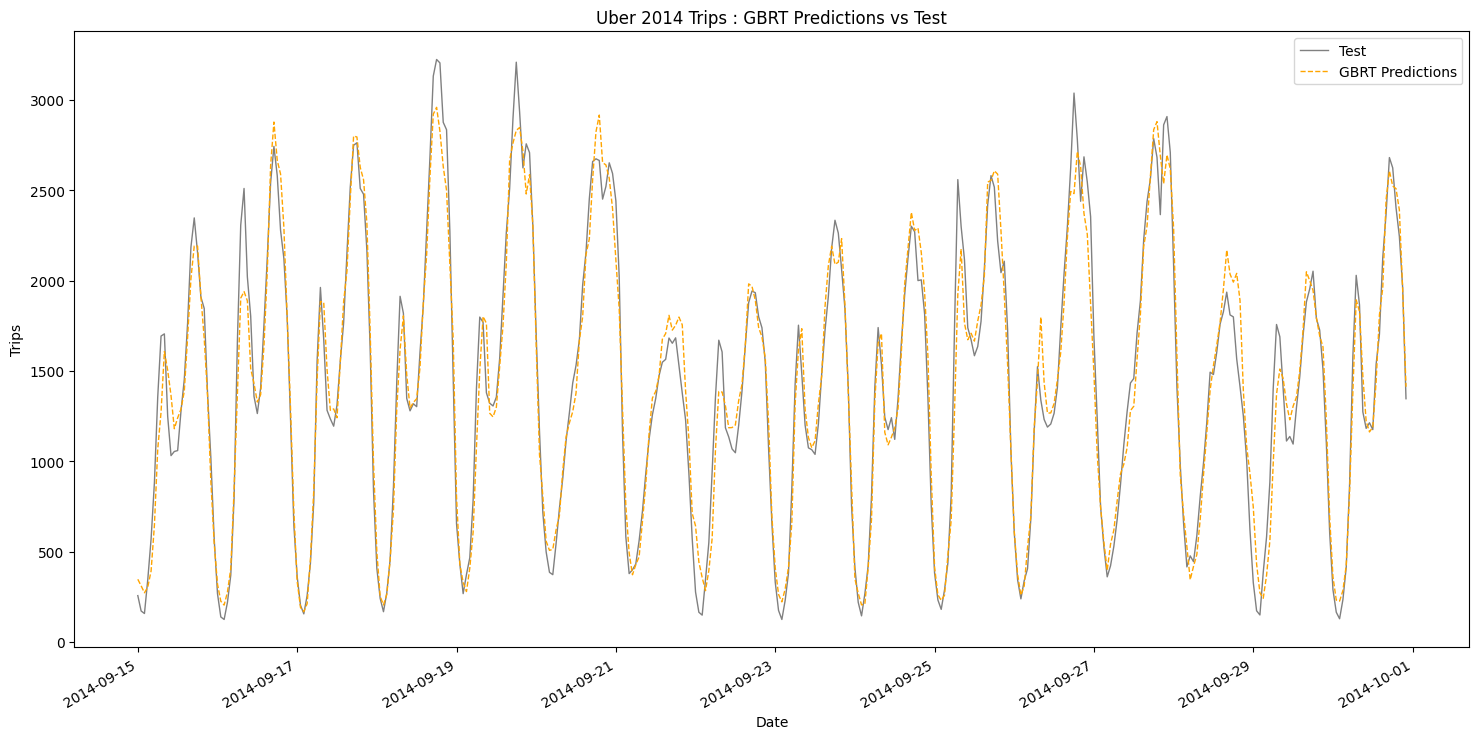

In [234]:
PlotPredictions([
    (uber2014_test.index,uber2014_test['Count'],'Test','-','gray'),
    (uber2014_test.index,gbr_predictions,'GBRT Predictions','--','orange')],
                'Uber 2014 Trips : GBRT Predictions vs Test')

In [235]:
gbr_mape=mean_absolute_percentage_error(y_test,gbr_predictions)
print(f'GBTR Percentage Error:\t{gbr_mape:.2%}')

GBTR Percentage Error:	13.29%


**Visualizing all models at once**

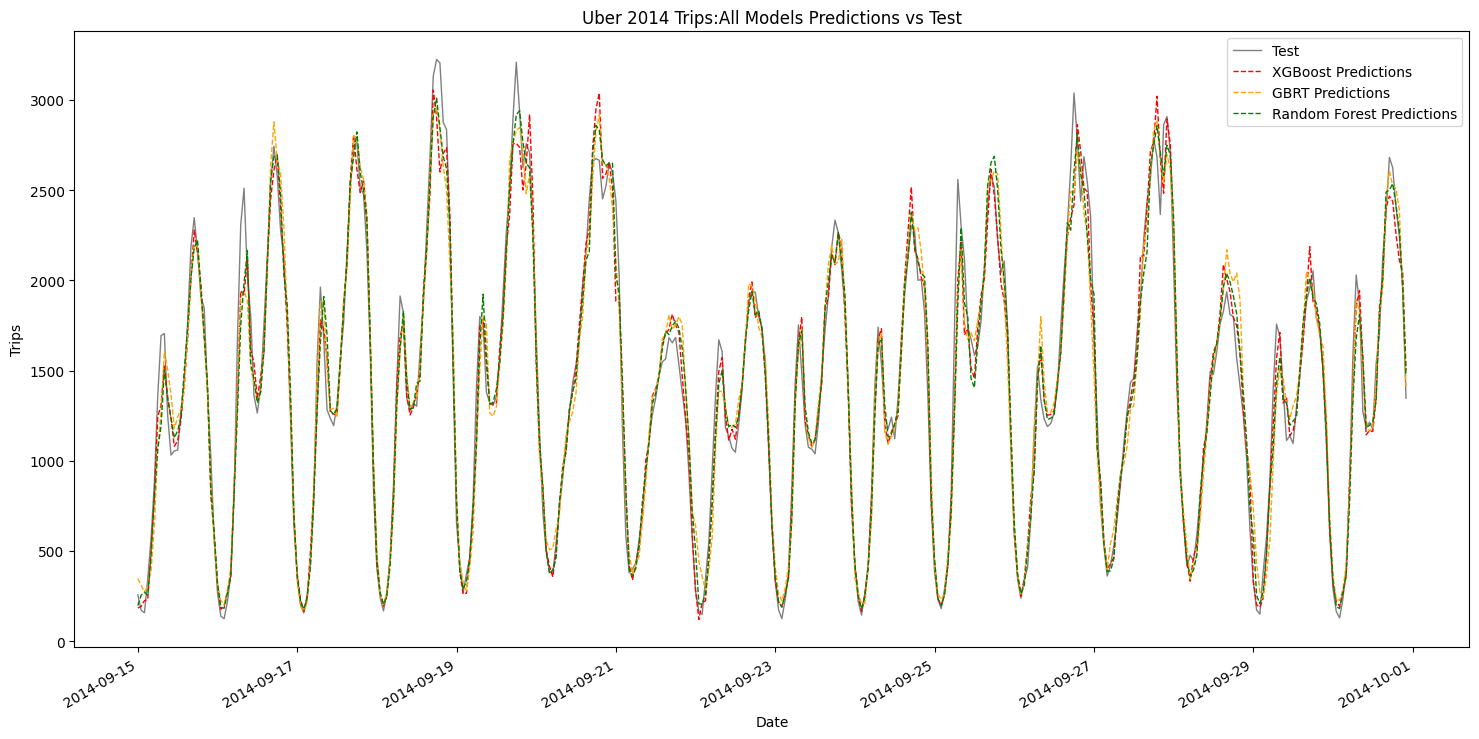

In [236]:
#Visualizing all models at once :

PlotPredictions([
    (uber2014_test.index,uber2014_test['Count'],'Test','-','gray'),
    (uber2014_test.index,xgb_predictions,'XGBoost Predictions','--','red'),
    (uber2014_test.index,gbr_predictions,'GBRT Predictions','--','Orange'),
    (uber2014_test.index,rf_predictions,'Random Forest Predictions','--','green')],
    'Uber 2014 Trips:All Models Predictions vs Test')

**Observation:**

**1.Trend Capture:**
All three models (XGBoost, GBTR, Random Forest) closely follow the overall pattern of the actual test data (gray line).
Peaks (rush hours) and valleys (low-demand hours) are well captured by the models.

**2. Model Comparison:**
XGBoost (red) and GBTR (orange) predictions are slightly more aligned with the test data at peak hours compared to Random Forest (green).
Random Forest tends to slightly underestimate the peaks but still follows the general trend.

**3. Consistency:**

All models show consistent predictions over time without erratic spikes or dips.
This suggests the models have learned the temporal pattern in the Uber trip data well.

**4.Error Behavior:**

Small deviations are visible during extremely high peaks or very low points, which is typical in regression predictions.
GBTR shows a slightly larger percentage error compared to XGBoost (as seen from your MAPE: 13.29%).

**5.Overall Performance:**

The ensemble approach or comparison indicates that while all models perform reasonably well, XGBoost appears slightly more accurate in following test data closely.


**Ensemble**

In [237]:
#Building the ensemble requires to understand how each algorithm has performed individually first.Then,decide how we can leverage 
#each one's strengths to our advantage.

print(f'XGBoost MAPE:\t\t\t{xgb_mape:.2%}')
print(f'Random Forest MAPE:\t\t{rf_mape:.2%}')
print(f'GBTR Percentage Error:\t\t{gbr_mape:.2%}')

XGBoost MAPE:			8.37%
Random Forest MAPE:		9.51%
GBTR Percentage Error:		13.29%


In [238]:
#Convert MAPE scores to weights:

xgb_mape=8.37
rf_mape=9.51
gbr_mape=13.29

print("Reciprocal of XGBoost MAPE=",1/xgb_mape)
print("Reciprocal of Random Forest MAPE =",1/rf_mape)
print("Reciprocal of GBTR MAPE =", 1/gbr_mape)


Reciprocal of XGBoost MAPE= 0.11947431302270013
Reciprocal of Random Forest MAPE = 0.10515247108307045
Reciprocal of GBTR MAPE = 0.07524454477050414


In [239]:
#adding all reciprocal values

0.119+0.105+0.075

0.299

In [240]:
#Calculate the weights
#weight= Reciprocal/ Total Reciprocal.sum()

# XGBoost Weight
0.119/0.299

0.3979933110367893

In [241]:
#Random Forest 
0.105/0.299

0.3511705685618729

In [242]:
#GBTR weight
0.075/0.299

0.2508361204013378

**observed :**

Model weighs were calculated using the reciprocal of MAPE values so that models with lower prediction error contribute more to the final ensemble prediction.

In [243]:
#Final weights

XBoost =0.40
RandomForest =0.35
GBTR=0.25

In [244]:
#Predictions into an array

predictions=np.array([
    xgb_predictions,
    rf_predictions,
    gbr_predictions
])

print(predictions)

[[ 183.55526733  193.26330566  224.91236877 ... 2112.81298828
  2041.06945801 1502.76403809]
 [ 197.78        254.8925      271.67866667 ... 2274.205
  1962.53777778 1471.095     ]
 [ 347.50954727  311.40522229  272.70411613 ... 2391.81347534
  1949.41761192 1413.38728811]]


In [245]:
#Final ensemble prediction

weights=np.array([0.40,0.35,0.25])

ensemble_prediction =(
   weights[0] * xgb_predictions + 
   weights[1] * rf_predictions + 
   weights[2] * gbr_predictions
)

print(ensemble_prediction[:10])

[ 229.52249375  244.36900284  253.22850988  257.70393083  466.56758366
  765.9703123  1137.11533645 1259.26041946 1541.6505671  1387.04021836]


**Obseravtion:**

Predictions from XGBoost, Random Forest and Gradient Boosting models were combined using a weighted avaerage based on model performance to create an esnsemble prediction.

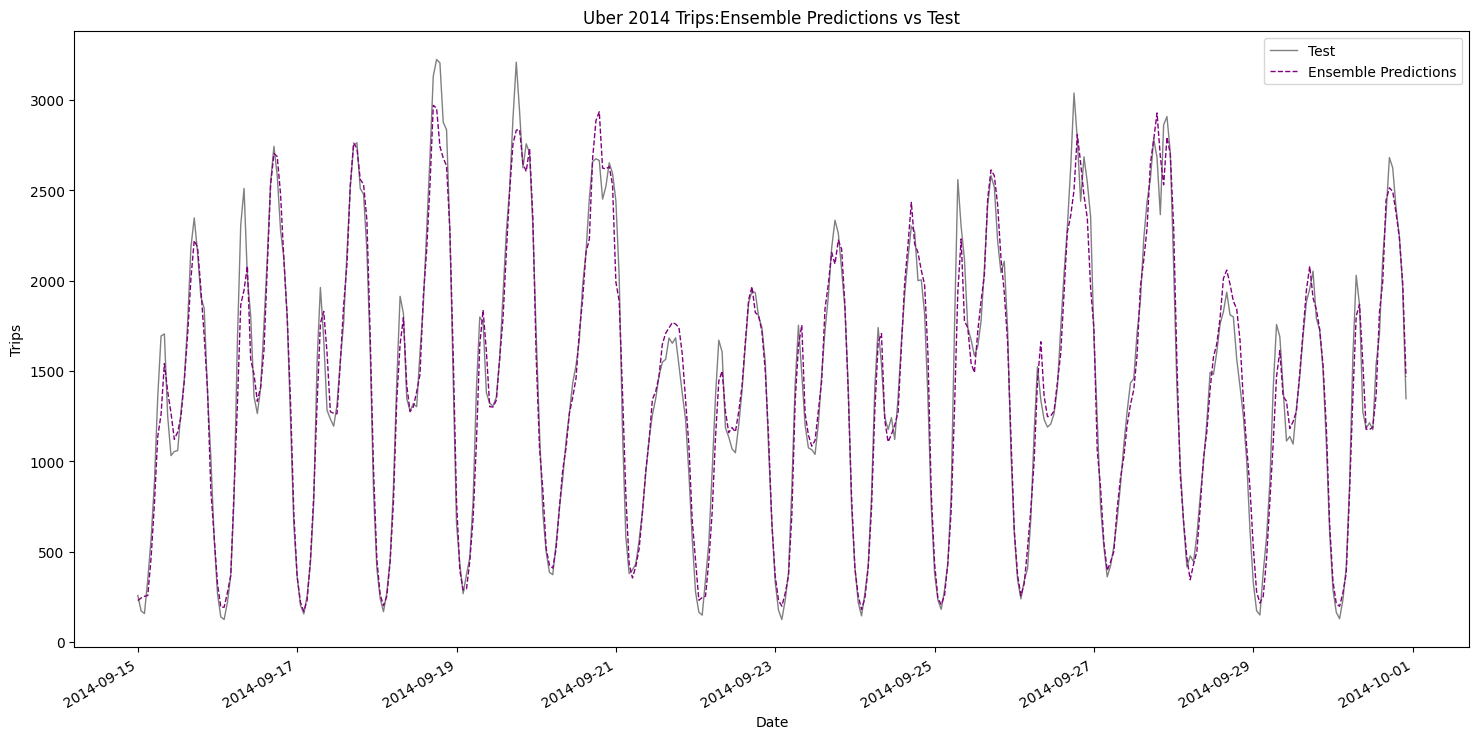

In [246]:
PlotPredictions([
    (uber2014_test.index, uber2014_test['Count'],'Test','-','gray'),
    (uber2014_test.index,ensemble_prediction,'Ensemble Predictions','--','purple')],
    'Uber 2014 Trips:Ensemble Predictions vs Test')

In [247]:
#Calculate MAPE for ensemble predictionson test set
ensemble_mape=mean_absolute_percentage_error(uber2014_test['Count'],
ensemble_prediction)

print(f'Ensemble MAPE:\t{ensemble_mape:.2%}')

Ensemble MAPE:	9.34%


In [249]:
#Calculate MAPE without multiplying by 100

from sklearn.metrics import mean_absolute_percentage_error
xgb_mape = mean_absolute_percentage_error(uber2014_test['Count'], xgb_predictions)
rf_mape = mean_absolute_percentage_error(uber2014_test['Count'], rf_predictions)
gbr_mape = mean_absolute_percentage_error(uber2014_test['Count'], gbr_predictions)
ensemble_mape = mean_absolute_percentage_error(uber2014_test['Count'], ensemble_prediction)

In [254]:
#Using Percentage formatting
print(f'XGBoost MAPE:\t\t{xgb_mape:.2%}')
print(f'Random Forest MAPE:\t{rf_mape:.2%}')
print(f'GBTR MAPE :\t\t{gbr_mape:.2%}')
print(f'Ensemble MAPE:\t\t{ensemble_mape:.2%}')

XGBoost MAPE:		8.37%
Random Forest MAPE:	9.51%
GBTR MAPE :		13.29%
Ensemble MAPE:		9.34%


**Observation:**

1.The performance of the machine learning models was evaluated using Mean Absolute Percentage Error (MAPE).Among the individual models, XGBoost achieved the lowest MAPE,indicating that it provides the most accurate predictions for uber trip demand in the dataset

2.The Random Forest model also performed well,with a slightly higher MAPE Compared to XGBoost,showing that ensemble tree-based models can effectively capture patterns in time-series demand data.

3.The Gradient Boosting Regressor (GBTR) showed comparatively higher error,suggestingt that it's predictive capability for this dataset is slightly weaker than the other models.

4.An ensemble model was then created by combining predictions from XGBoot, Random Forest, and Gradient Boosting using a weighted average. The ensemble model achieved a MAPE of approximately 9.34%, demonstrating stable and reliable prediction performance by leveraging the strengths of multiple models.

Overall, the results indicate that tree-based ensemble models are highly effective for forecasting Uber trip demand,and combining multiple models can improve prediction robustness.

**Insights and Conclusions from Training and Evaluation**

**Ensemble Model :**

The esemble model achieved a MAPE of 9.34%, Which is lower than the errors produced by the Random Forest and Gradient Boosting Regressor models.This indicates that the ensemble approach improves prediction accuracy by combining the strengths of multiple models.

The ensemble model integrates predictions from XGBoost,Random Forest, and Gradient Boosting Regressor,allowing it to capture different patterns in the dataset and produce more reliable forecasts.

By leveraging the complementary strengths of these models,the ensemble approach provides more stable and robust predictions for Uber trip demand forecasting.

**Impact of Window-Based Logic:**

Applying window-based logic to model training has effectively captured temporal dependencies in the
data, resulting in enhanced predictive accuracy across all models.

Thisapproach ensures that the models can better handle seasonality and trends, which is crucial for
accurate time series forecasting, particularly in dynamic contexts like ride-sharing demand.

**Cross-Validation & Parameter Tuning:**


Cross-validation ensured reliable model evaluation and reduced overfitting. Parameter tuning improved the performance of XGBoost and GBTR.

**Practical Implications:**

XGBoost is recommended for applications requiring the lowest prediction error. The ensemble model provides stable and reliable predictions by combining strengths of multiple models.